In [46]:
# =========================
# Basic Libraries
# =========================
import numpy as np
import pandas as pd

# Display settings
pd.set_option('display.max_columns', None)

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# =========================
# Sklearn - Preprocessing
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# Handling Imbalanced Data
# =========================
from imblearn.over_sampling import SMOTE
from collections import Counter

# =========================
# ML Algorithms
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# =========================
# Evaluation Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================
# Model Saving
# =========================
import pickle

# =========================
# Ignore Warnings
# =========================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv("fetal_health.csv")

# Check first 5 rows
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,2.4,64,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,10.4,130,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,13.4,130,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,23.0,117,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,19.9,117,53,170,9,0,137,136,138,11,1,1


In [17]:
# Shape of dataset
print("Shape:", df.shape)

# Info
df.info()

# Check missing values
df.isnull().sum()

Shape: (2126, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   int64  
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   int64  
 8   mean_value_of_short_

,0
baseline value,0
accelerations,0
fetal_movement,0
uterine_contractions,0
light_decelerations,0
severe_decelerations,0
prolongued_decelerations,0
abnormal_short_term_variability,0
mean_value_of_short_term_variability,0
percentage_of_time_with_abnormal_long_term_variability,0


In [18]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


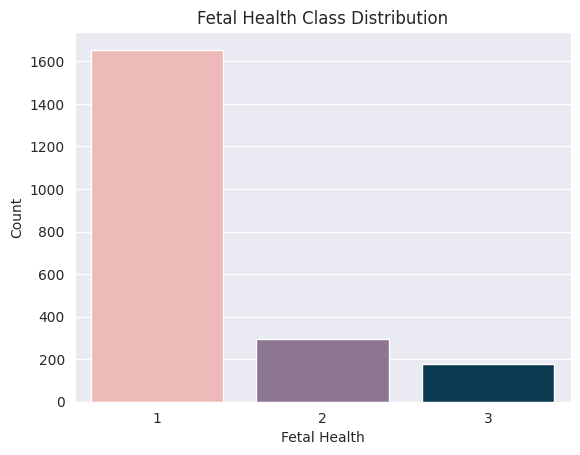

In [36]:
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

# first evaluate target variable to check imbalance
df['fetal_health'].value_counts()
colours = ["#f7b2b0", "#8f7198", "#003f5c"]
sns.countplot(data=df, x="fetal_health", palette=colours)

plt.title("Fetal Health Class Distribution")
plt.xlabel("Fetal Health")
plt.ylabel("Count")

plt.show()

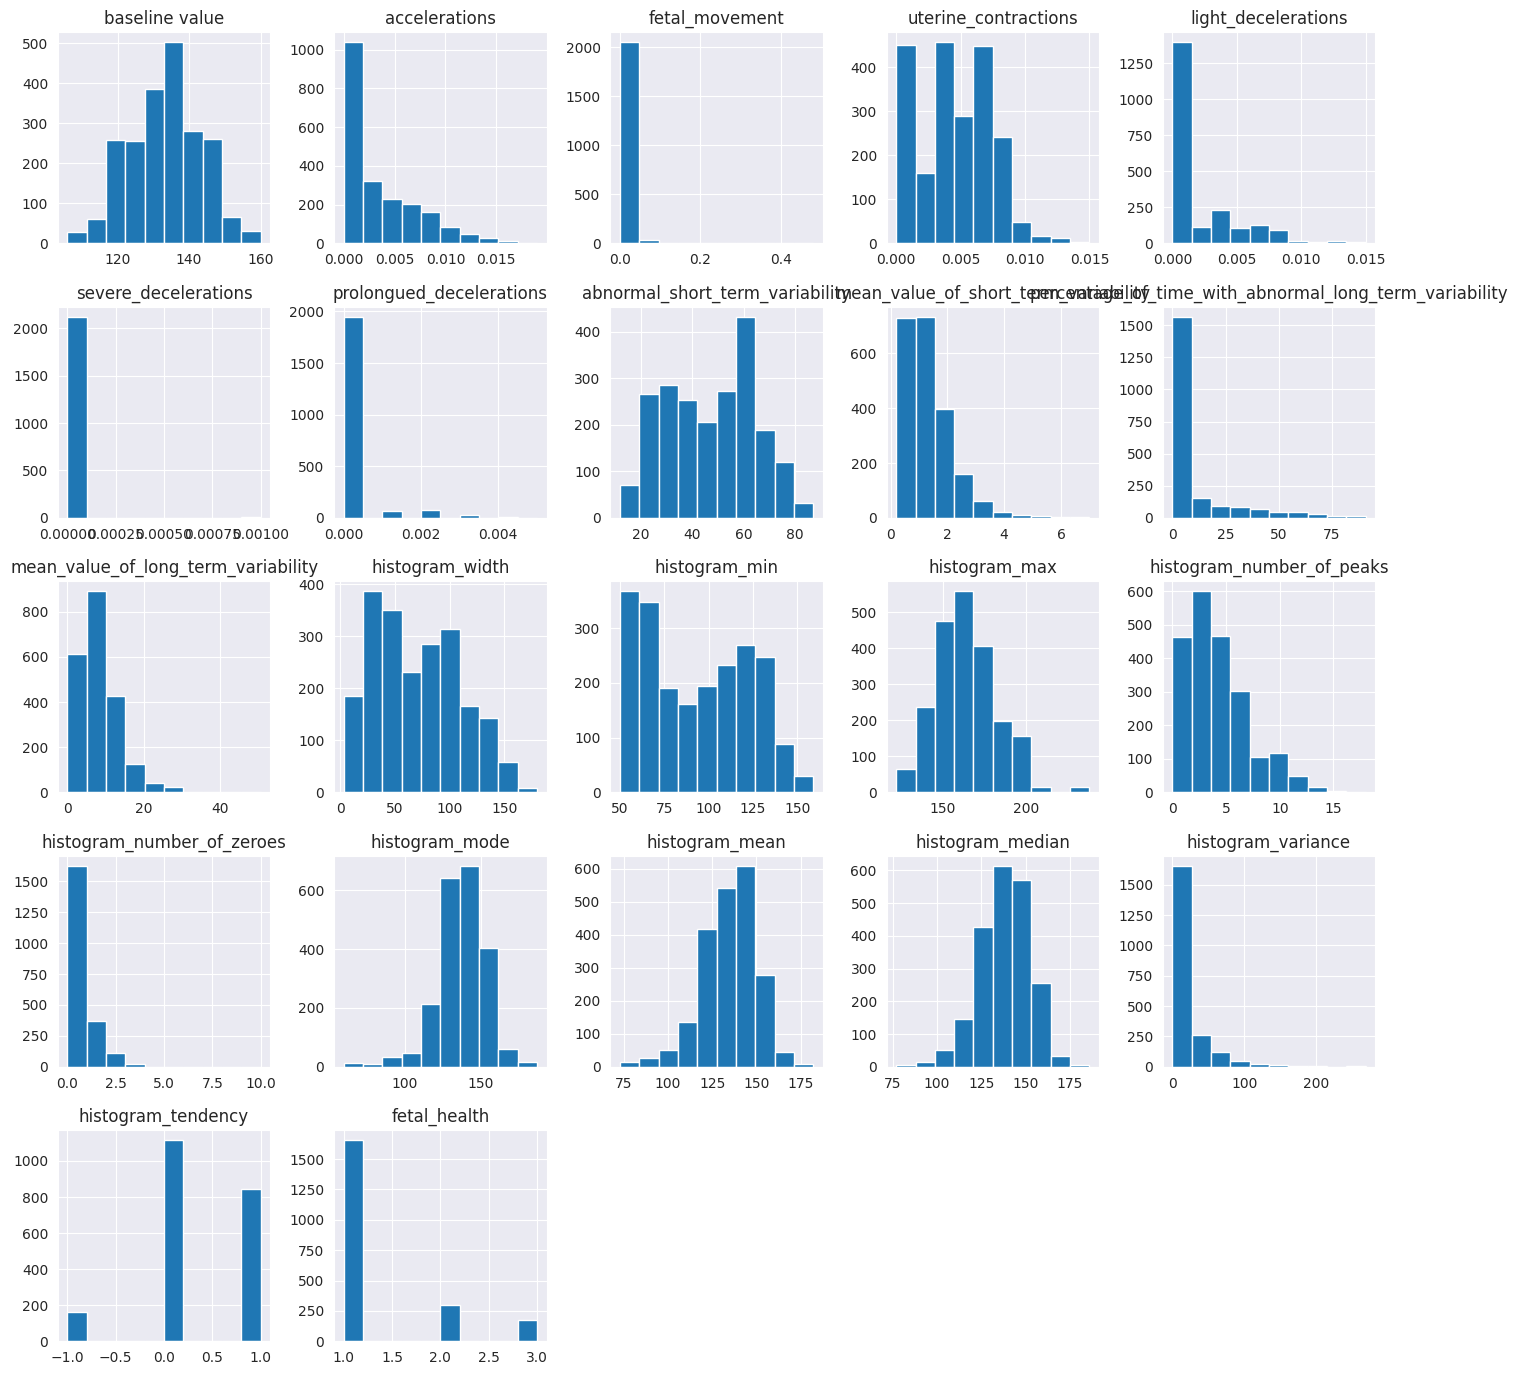

In [21]:
df.hist(figsize=(17,17), layout=(5,5), sharex=False);
plt.hist(df['accelerations'], bins=30)
plt.title("Distribution of Accelerations")
plt.show()

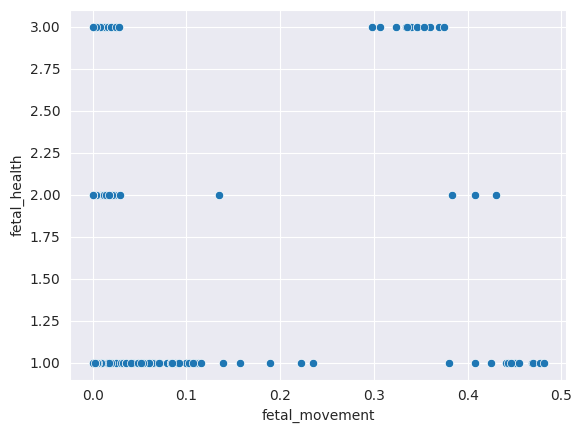

In [22]:
sns.scatterplot(x="fetal_movement", y="fetal_health", data=df)
plt.show()

<Axes: >

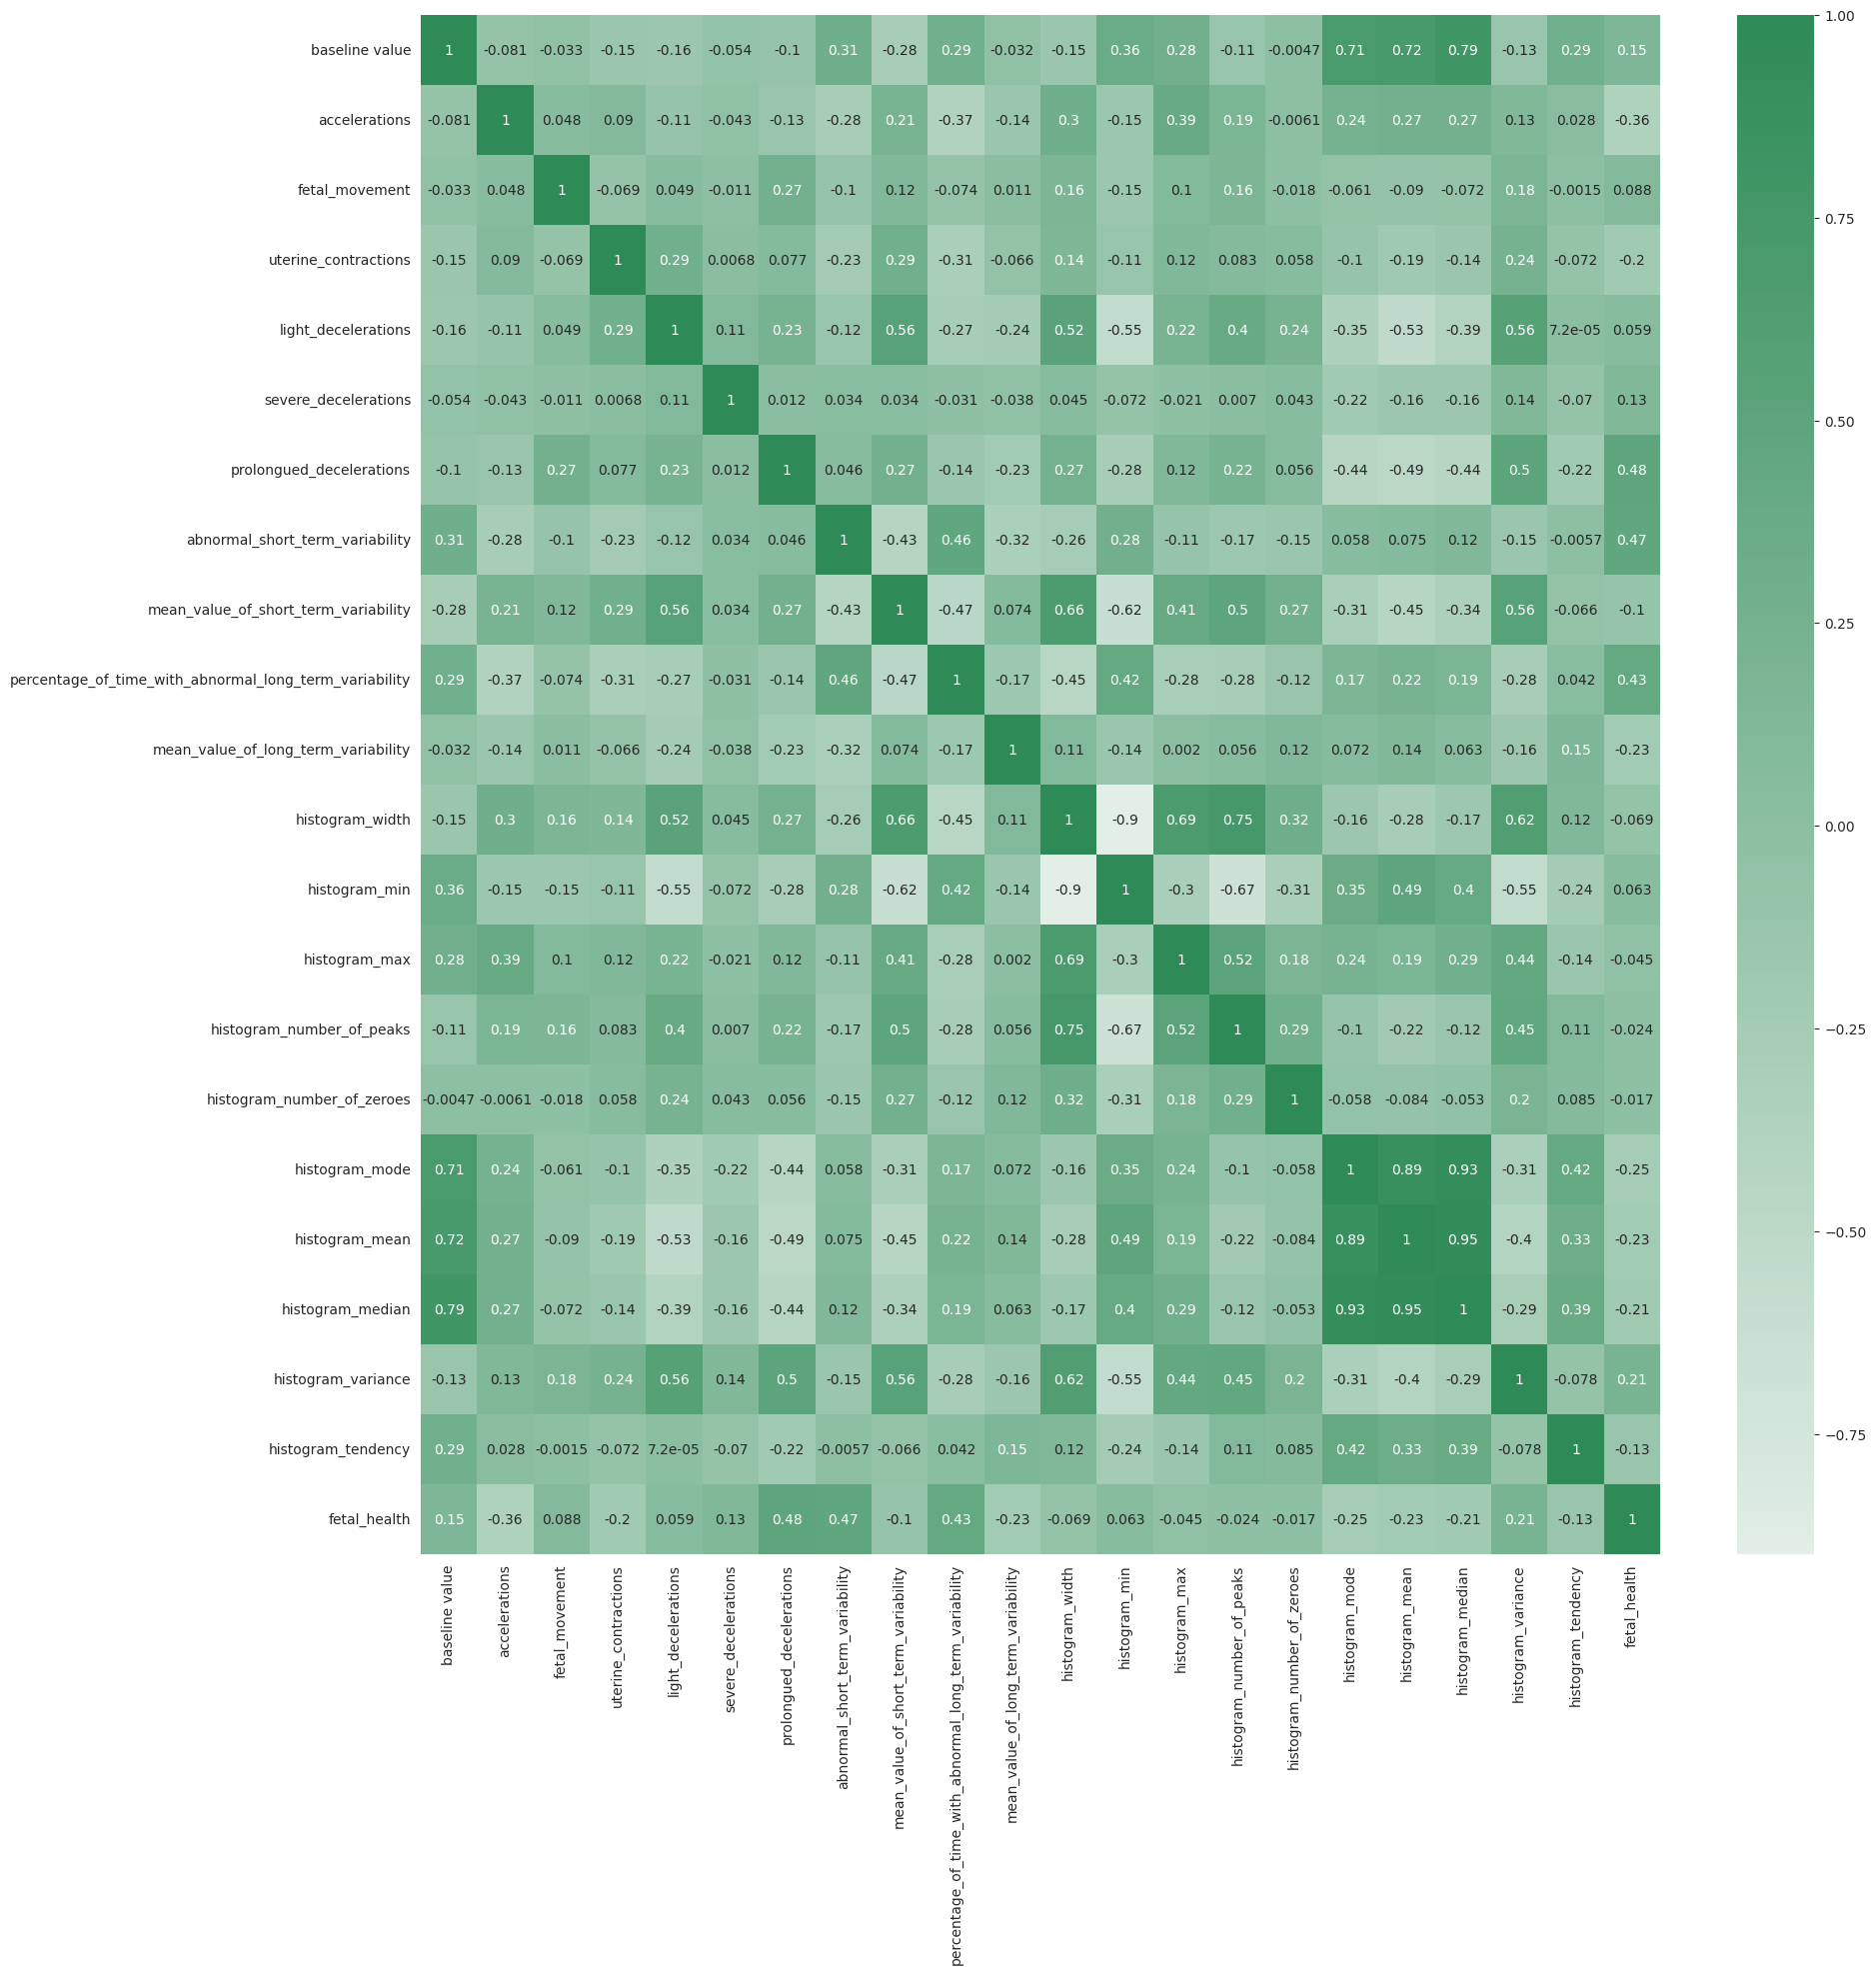

In [23]:
corrmat = df.corr()
plt.figure(figsize=(20,20))
cmap = sns.light_palette("seagreen", as_cmap=True)
sns.heatmap(corrmat, annot=True, cmap=cmap, center=0)

In [30]:
df.drop(columns=['histogram_mean'], axis=1, inplace=True)

KeyError: "['histogram_mean'] not found in axis"

In [32]:
df.corr()['fetal_health'].sort_values(ascending=False)

,fetal_health
fetal_health,1.000000
prolongued_decelerations,0.484859
abnormal_short_term_variability,0.471191
percentage_of_time_with_abnormal_long_term_variability,0.426146
histogram_variance,0.206630
baseline value,0.148151
severe_decelerations,0.131934
fetal_movement,0.088010
histogram_min,0.063175
light_decelerations,0.058870


In [34]:
new_data = df.loc[:,[
'prolongued_decelerations',
'abnormal_short_term_variability',
'percentage_of_time_with_abnormal_long_term_variability',
'histogram_variance',
'histogram_median',
'mean_value_of_long_term_variability',
'histogram_mode',
'accelerations',
'fetal_health'
]]
new_data.head()

,prolongued_decelerations,abnormal_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,histogram_variance,histogram_median,mean_value_of_long_term_variability,histogram_mode,accelerations,fetal_health
0,0.0,73,43,73,121,2.4,120,0.000,2
1,0.0,17,0,12,140,10.4,141,0.006,1
2,0.0,16,0,13,138,13.4,141,0.003,1
3,0.0,16,0,13,137,23.0,137,0.003,1
4,0.0,16,0,11,138,19.9,137,0.007,1


In [35]:
X = df.drop(columns=['fetal_health'])
y = df['fetal_health']

from sklearn.preprocessing import MinMaxScaler

scale = MinMaxScaler()

X_scaled = pd.DataFrame(
scale.fit_transform(X),
columns=X.columns
)
X_scaled.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,mean_value_of_long_term_variability,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_median,histogram_variance,histogram_tendency
0,0.259259,0.000000,0.0,0.000000,0.0,0.0,0.0,0.813333,0.044118,0.472527,0.047337,0.344633,0.110092,0.034483,0.111111,0.0,0.472441,0.403670,0.271375,1.0
1,0.481481,0.315789,0.0,0.400000,0.2,0.0,0.0,0.066667,0.279412,0.000000,0.205128,0.717514,0.165138,0.655172,0.333333,0.1,0.637795,0.577982,0.044610,0.5
2,0.500000,0.157895,0.0,0.533333,0.2,0.0,0.0,0.053333,0.279412,0.000000,0.264300,0.717514,0.165138,0.655172,0.277778,0.1,0.637795,0.559633,0.048327,0.5
3,0.518519,0.157895,0.0,0.533333,0.2,0.0,0.0,0.053333,0.323529,0.000000,0.453649,0.644068,0.027523,0.413793,0.611111,0.0,0.606299,0.550459,0.048327,1.0
4,0.481481,0.368421,0.0,0.533333,0.0,0.0,0.0,0.053333,0.323529,0.000000,0.392505,0.644068,0.027523,0.413793,0.500000,0.0,0.606299,0.559633,0.040892,1.0


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=10
)

In [41]:
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(
X_train.astype('float'),
y_train
)
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({1: 1158, 2: 201, 3: 129})
After SMOTE: Counter({1: 1158, 2: 1158, 3: 1158})


Random Forest Accuracy: 0.9498432601880877
for the amount of training data is 3474
Accuracy of RandomForestClassifier 0.9498432601880877


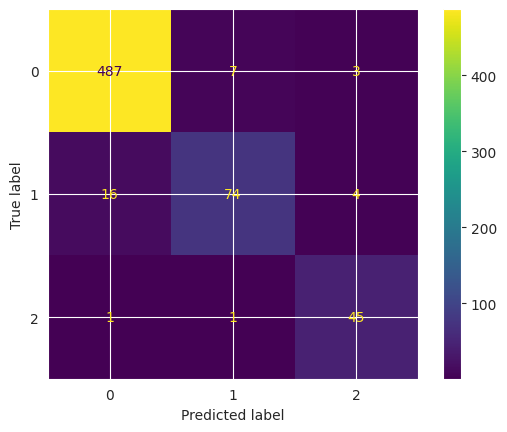

In [47]:
RF_model = RandomForestClassifier()
RF_model.fit(X_train_smote, y_train_smote)
rf_pred = RF_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))
print ("for the amount of training data is", len(y_train_smote))
print("Accuracy of RandomForestClassifier",RF_model.score(X_test,y_test))
cm = confusion_matrix(y_test,rf_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

Decision Tree Accuracy: 0.9075235109717869
for the amount of training data is 3474
Accuracy of DecisionTreeClassifier 0.9075235109717869


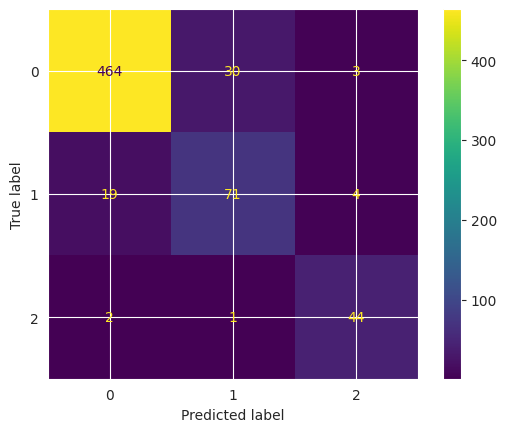

In [48]:
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train_smote, y_train_smote)
dt_pred = DT_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))
print ("for the amount of training data is", len(y_train_smote))
print("Accuracy of DecisionTreeClassifier",DT_model.score(X_test,y_test))
cm = confusion_matrix(y_test,dt_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

Logistic Regression Accuracy: 0.8056426332288401
for the amount of training data is 3474
Accuracy of LogisticRegression 0.8056426332288401


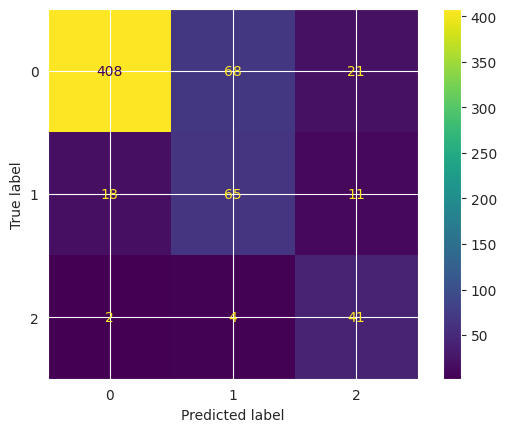

In [50]:
LR_model = LogisticRegression()
LR_model.fit(X_train_smote, y_train_smote)
lr_pred = LR_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))
print ("for the amount of training data is", len(y_train_smote))
print("Accuracy of LogisticRegression",LR_model.score(X_test,y_test))
cm = confusion_matrix(y_test,lr_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

KNN Accuracy: 0.8714733542319749
for the amount of training data is 3474
Accuracy of KNeighborsClassifier 0.8714733542319749


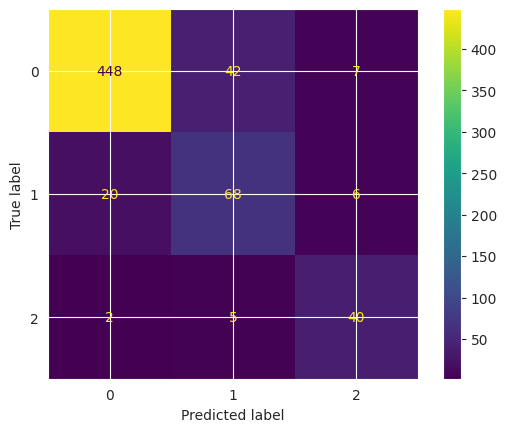

In [52]:
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train_smote, y_train_smote)
knn_pred = KNN_model.predict(X_test)
print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))
print ("for the amount of training data is", len(y_train_smote))
print("Accuracy of KNeighborsClassifier",KNN_model.score(X_test,y_test))
cm = confusion_matrix(y_test,knn_pred)
cm_display = ConfusionMatrixDisplay(cm).plot()
plt.show()

In [57]:
RF_model.predict([
[0.345,0.1225,23346,0.23456,0.987,2345,123,0,0.000,0.0,73.0,43.0,2.4,73.0,120.0,121.0,0,123,0,0.345]
])

array([1])

In [53]:
print("RF :", accuracy_score(y_test,rf_pred))

print("DT :", accuracy_score(y_test,dt_pred))

print("LR :", accuracy_score(y_test,lr_pred))

print("KNN:", accuracy_score(y_test,knn_pred))

RF : 0.9498432601880877
DT : 0.9075235109717869
LR : 0.8056426332288401
KNN: 0.8714733542319749


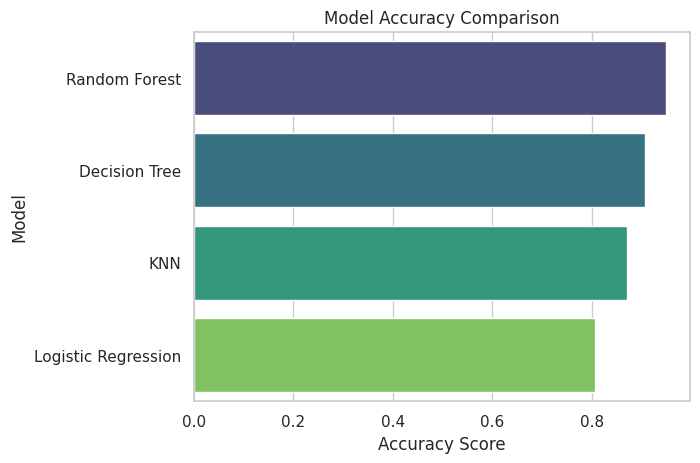

In [61]:
sns.set(style = "whitegrid")

# Create a DataFrame for model accuracies
model_names = ['Random Forest', 'Decision Tree', 'Logistic Regression', 'KNN']
accuracy_scores = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, knn_pred)
]

accuracy_df = pd.DataFrame({
    'name': model_names,
    'score': accuracy_scores
})

# Sort the DataFrame by score for better visualization
accuracy_df = accuracy_df.sort_values(by='score', ascending=False)

ax = sns.barplot(
    y="name",
    x="score",
    data=accuracy_df,
    palette="viridis"
)
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy Score')
plt.ylabel('Model')
plt.show()

In [62]:
pickle.dump(RF_model,open('fetal_health_model.pkl','wb'))